In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]


# Q11: Which store locations generated the highest total sales revenue?

In [9]:
# code for Query 11
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$storeLocation",
            "Total Sales Revenue": {
                "$sum": {
                    "$multiply": [{"$toDouble":"$items.price"}, "$items.quantity"]
                }
            }
        }
    },
    {
        "$sort": {
            "Total Sales Revenue": -1
        }
    }
]

store = list(collection.aggregate(pipeline))
pprint(store)

store_df = pd.DataFrame(store)  
store_df = store_df.rename(columns={"_id": "Store Location", "Total Sales Revenue": "Total Sales Revenue"})

store_df

[{'Total Sales Revenue': 2921009.92, '_id': 'Denver'},
 {'Total Sales Revenue': 2255947.69, '_id': 'Seattle'},
 {'Total Sales Revenue': 1583066.79, '_id': 'London'},
 {'Total Sales Revenue': 1445603.11, '_id': 'Austin'},
 {'Total Sales Revenue': 1016059.59, '_id': 'New York'},
 {'Total Sales Revenue': 672885.17, '_id': 'San Diego'}]


,Store Location,Total Sales Revenue
0,Denver,2921009.92
1,Seattle,2255947.69
2,London,1583066.79
3,Austin,1445603.11
4,New York,1016059.59
5,San Diego,672885.17


In [11]:
data = store_df["Store Location"].tolist()

print(f"Store Locations with the highest total sales revenue: **{data[0]}** and **{data[1]}**")

Store Locations with the highest total sales revenue: **Denver** and **Seattle**


## Code for Visualization

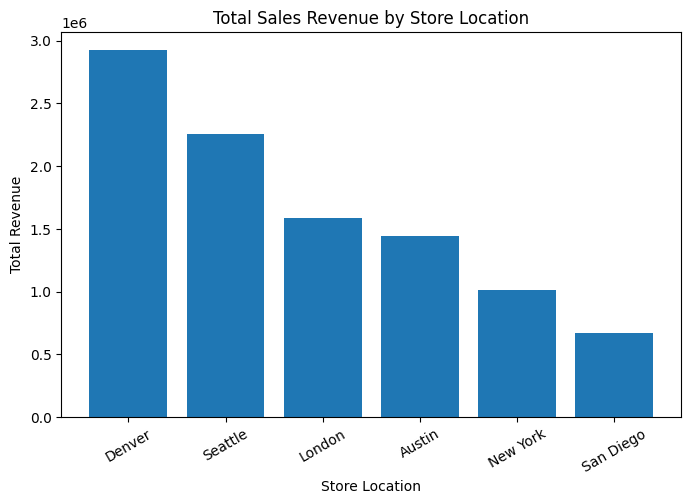

In [14]:
plt.figure(figsize=(8,5))

plt.bar(store_df["Store Location"], store_df["Total Sales Revenue"])

plt.title("Total Sales Revenue by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.show()